In [ ]:
# Supplementary exploration: metformin/LDL gradient within Cluster 0
# This is explicitly secondary/exploratory and does not revisit the K=3 decision

# Standard library
import sys
from pathlib import Path

# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from scipy.stats import mannwhitneyu

# Clustering and dimensionality reduction
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Project-local setup
sys.path.append("../src")
from plot_style import set_project_style, COLOR_DARK, COLOR_ACCENT, COLOR_BG, COLOR_GRAY

set_project_style()
data_dir = Path("../data/processed")


patient_features = pd.read_parquet("../data/processed/patient_features_clustered.parquet")

cluster0 = patient_features[patient_features["cluster_label"] == "Mild, lower treatment intensity"].copy()
print(f"Cluster 0 subset: {cluster0.shape[0]} patients")

Cluster 0 subset: 1303 patients


In [14]:
# [Step 2] (per plan): compare on_metformin=0 vs on_metformin=1 within Cluster 0,
# across the lipid/glycemic panel, not just LDL, to check whether the
# difference is an isolated artifact or a coherent metabolic signal.
# Mann-Whitney U (not a t-test): several of these variables are right-skewed
# (Phase 3 EDA). Rank-biserial r reported alongside p-value: with n=1303, even
# small, clinically negligible differences can reach statistical significance,
# so the effect size matters more than the p-value alone here.

panel_cols = ["LDL", "HDL", "Triglycerides", "HbA1c", "Glucose", "BMI"]

group0 = cluster0[cluster0["on_metformin"] == 0]
group1 = cluster0[cluster0["on_metformin"] == 1]

results = []
for col in panel_cols:
    u_stat, p_value = mannwhitneyu(group0[col], group1[col], alternative="two-sided")
    n0, n1 = len(group0), len(group1)
    rank_biserial = 1 - (2 * u_stat) / (n0 * n1)
    results.append({
        "variable": col,
        "median_no_metformin": group0[col].median(),
        "median_on_metformin": group1[col].median(),
        "p_value": round(p_value, 4),
        "rank_biserial_r": round(rank_biserial, 3),
    })

pd.DataFrame(results)

,variable,median_no_metformin,median_on_metformin,p_value,rank_biserial_r
0,LDL,131.50,103.9,0.0,-0.429
1,HDL,50.20,53.4,0.0,0.158
2,Triglycerides,170.15,128.7,0.0,-0.683
3,HbA1c,6.90,5.9,0.0,-0.580
4,Glucose,111.45,84.2,0.0,-0.793
5,BMI,27.80,30.0,0.0,0.661


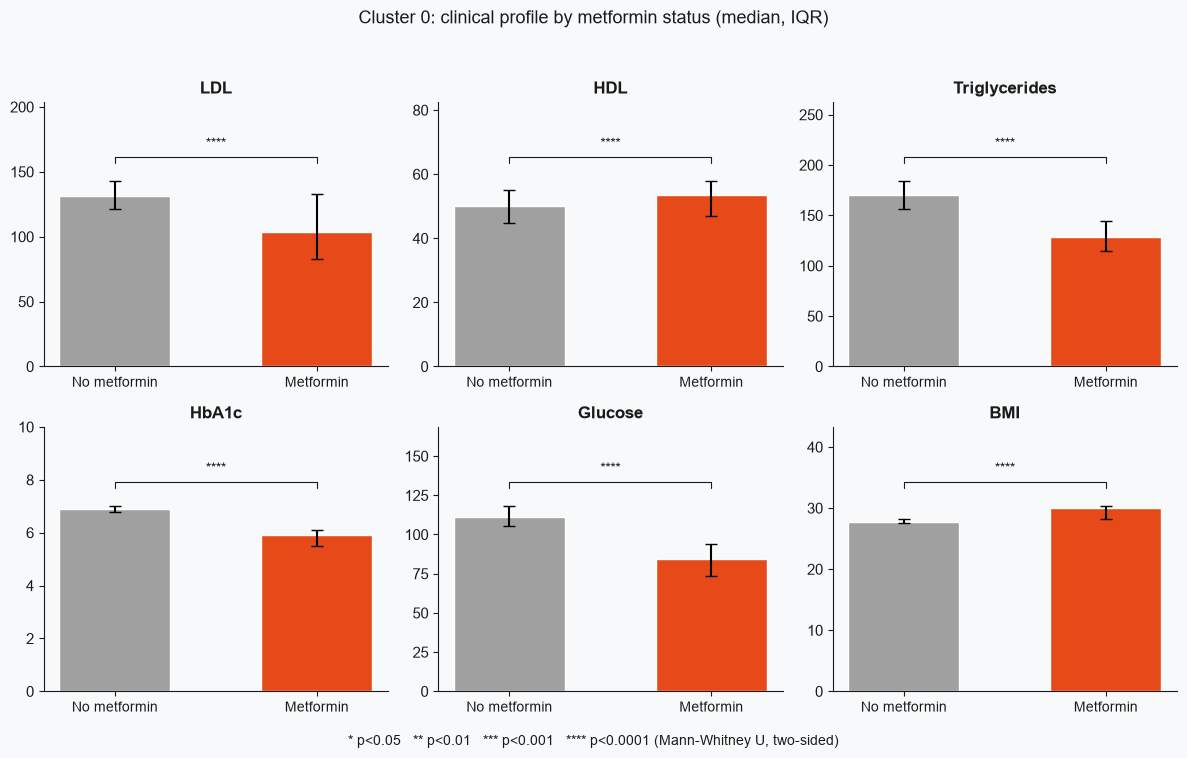

In [21]:
# [Step 2a] Visual comparison of clinical profile by metformin status (Cluster 0)
# same variables and order as the Step 2 Mann-Whitney table
continuous_vars = ["LDL", "HDL", "Triglycerides", "HbA1c", "Glucose", "BMI"]


def p_to_stars(p):
    """Map a p-value to conventional significance star notation."""
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def add_significance_bracket(ax, x1, x2, y, label):
    """Draw a horizontal bracket between two bars with a centered label above it."""
    ax.plot([x1, x1, x2, x2], [y, y * 1.03, y * 1.03, y], color=COLOR_DARK, lw=0.8)
    ax.text((x1 + x2) / 2, y * 1.06, label, ha="center", va="bottom", fontsize=10)


fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for var, ax in zip(continuous_vars, axes.flat):
    group0 = cluster0.loc[cluster0["on_metformin"] == 0, var]
    group1 = cluster0.loc[cluster0["on_metformin"] == 1, var]

    # median + IQR as error bars, consistent with the rank-based test below
    med = [group0.median(), group1.median()]
    q25 = [group0.quantile(0.25), group1.quantile(0.25)]
    q75 = [group0.quantile(0.75), group1.quantile(0.75)]
    err_lower = [m - q for m, q in zip(med, q25)]
    err_upper = [q - m for q, m in zip(q75, med)]

    _, p_value = mannwhitneyu(group0, group1, alternative="two-sided")

    ax.bar([0, 1], med, yerr=[err_lower, err_upper], capsize=4,
           color=[COLOR_GRAY, ACCENT], width=0.55)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No metformin", "Metformin"], fontsize=10)
    ax.set_title(var, fontsize=12)
    sns.despine(ax=ax)

    bracket_y = max(q75) * 1.1
    ax.set_ylim(top=bracket_y * 1.3)
    add_significance_bracket(ax, 0, 1, bracket_y, p_to_stars(p_value))

fig.suptitle("Cluster 0: clinical profile by metformin status (median, IQR)", y=1.03)
fig.text(0.5, -0.02,
          "* p<0.05   ** p<0.01   *** p<0.001   **** p<0.0001 (Mann-Whitney U, two-sided)",
          ha="center", fontsize=10, color=COLOR_DARK)

plt.tight_layout()
plt.show()

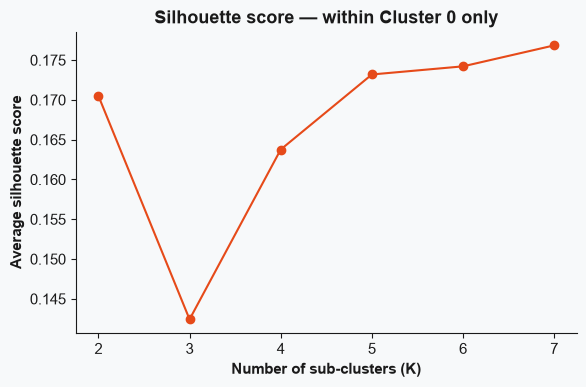

In [3]:
# [Step 3] (per plan): recursive clustering within Cluster 0 only, on continuous
# clinical features (on_metformin excluded as input, profiling variable, not
# a clustering feature, same logic as the main analysis).
#
# IMPORTANT: RobustScaler is re-fit on this subset alone, not reused from the
# full-cohort scaler. Cluster 0 is, by construction, the low-severity slice of
# the cohort, reusing the global scale would compress whatever internal
# variation exists here even further, hiding exactly the structure we're
# trying to detect.

continuous_cols = [
    "AGE", "HbA1c", "Glucose", "BMI", "LDL", "HDL",
    "Triglycerides", "Creatinine", "CCI", "encounters_per_year_log",
]

cluster0_scaled = cluster0[continuous_cols].copy()
local_scaler = RobustScaler()
cluster0_scaled[continuous_cols] = local_scaler.fit_transform(cluster0_scaled[continuous_cols])

k_range = range(2, 8)
local_silhouettes = []
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(cluster0_scaled)
    local_silhouettes.append(silhouette_score(cluster0_scaled, labels))

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), local_silhouettes, marker="o", color="#E64A19")
plt.title("Silhouette score — within Cluster 0 only")
plt.xlabel("Number of sub-clusters (K)")
plt.ylabel("Average silhouette score")
plt.tight_layout()
plt.show()

**Recursive clustering within Cluster 0: conclusion**

Silhouette scores (K=2 to 7, locally-scaled continuous features) remain below 0.18
across the board — well under the 0.25 "reasonable structure" threshold (Kaufman &
Rousseeuw) and under the 0.265 achieved by the main K=3 solution. The curve dips at
K=3 and then rises monotonically through K=7, the classic signature of no genuine
substructure: at higher K, KMeans peels off small groups of peripheral outliers into
tight, artificially high-silhouette micro-clusters rather than recovering a real
phenotype.

**Preliminary conclusion**: the metformin-associated metabolic gradient found in
Step 2 is not a discrete sub-cluster. Step 4 (visual check) will confirm this
qualitatively before final classification (Step 5).

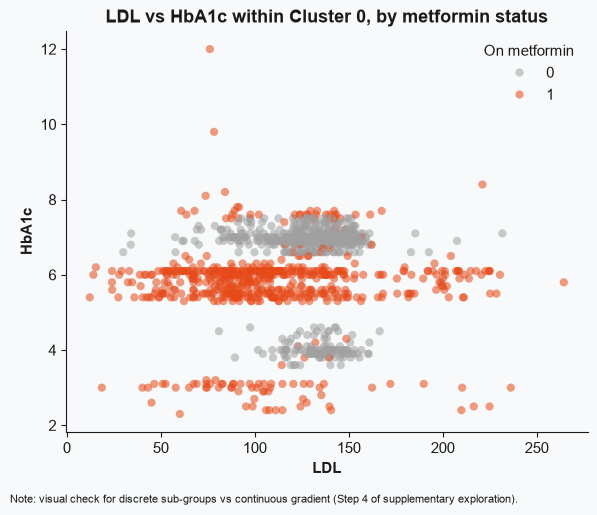

In [23]:
# [Step 4] - Visual check: Check 1

fig, ax = plt.subplots(figsize=(6, 5))

sns.scatterplot(
    data=cluster0,
    x="LDL",
    y="HbA1c",
    hue="on_metformin",
    palette={0: COLOR_GRAY, 1: COLOR_ACCENT},
    alpha=0.55,       # transparency exposes overlap density, not just point count
    edgecolor="none", # avoids visual clutter at this point density
    s=35,
    ax=ax,
)

ax.set_title("LDL vs HbA1c within Cluster 0, by metformin status")
ax.legend(title="On metformin", loc="upper right", frameon=False)
sns.despine(ax=ax)  # remove top/right spines, in line with data-ink minimization

fig.text(
    0.01, -0.02,
    "Note: visual check for discrete sub-groups vs continuous gradient (Step 4 of supplementary exploration).",
    fontsize=8, color=COLOR_DARK,
)

plt.tight_layout()
plt.show()

**Reading this plot: discrete sub-group or continuous gradient?**

A genuine discrete sub-phenotype would appear here as two well-separated point
clouds, one per `on_metformin` value, with little or no overlap between them,
analogous to two distinct populations rather than one population with internal
variation.

What we observe instead is horizontal banding along the HbA1c axis (roughly
3.5-4.5, 5.3-6.5, and 6.7-7.8), with each band spanning nearly the full LDL
range (50-200). Two observations follow from this:

- The apparent structure lives almost entirely on a single axis (HbA1c), not
  jointly across LDL and HbA1c as a true sub-phenotype would require.
- Within each band, `on_metformin=0` and `on_metformin=1` points overlap
  substantially rather than mapping cleanly to separate bands, there is a
  density tendency (the central band skews toward `on_metformin=1`, the
  upper band toward `on_metformin=0`), but no clean partition.

**Interpretation**: this pattern is inconsistent with a discrete sub-cluster
and is instead compatible with two overlapping, independent phenomena, addressed
further in the next figure.

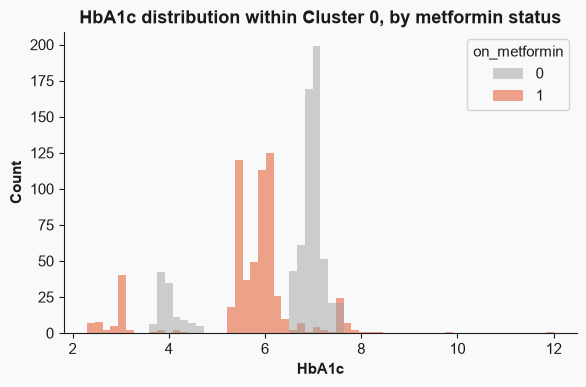

In [24]:
# [Step 4] - Visual check: Check 2

fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    data=cluster0,
    x="HbA1c",
    hue="on_metformin",
    palette={0: COLOR_GRAY, 1: COLOR_ACCENT},
    multiple="layer",   # overlapping, not stacked: compares shapes directly
    bins=60,             # fine enough to reveal banding, if real
    alpha=0.5,
    edgecolor="none",
    ax=ax,
)

ax.set_title("HbA1c distribution within Cluster 0, by metformin status")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Disentangling the HbA1c banding from the metformin effect**

Each `on_metformin` group is itself multimodal: `on_metformin=0` shows peaks
near HbA1c 4 and 7; `on_metformin=1` shows peaks near HbA1c 3 and 6. If the
metformin effect alone explained this banding, each group would be expected
to show a single, clean peak, with the two groups cleanly separated. Instead,
both groups share the same underlying multi-peak structure, strong evidence
that the banding itself is independent of metformin status, and consistent
with the BMI bimodality already flagged as a likely Synthea data-generation
artifact (discrete clinical-state modules producing near-categorical synthetic
values).

The metformin-associated signal is visible separately, as a consistent
~1-point downward shift between corresponding peaks (4→3, 7→6), the same
underlying distribution, shifted rather than split. This parallel-shift
pattern is the signature of a continuous gradient, not a new discrete
sub-group: an effect analogous to comparing height distributions between two
populations that differ on average but substantially overlap, rather than two
non-overlapping populations.

**Conclusion**: combined with the low, monotonically increasing silhouette
scores from Step 3 (no genuine multivariate separability), this confirms
classification (b), a continuous, treatment-associated gradient overlaid on
an independent dataset-generation artifact, not a discrete sub-phenotype
warranting separate clustering treatment.

In [6]:
# how many distinct HbA1c values, and how are they distributed numerically?
print("n unique HbA1c values:", cluster0["HbA1c"].nunique())
print("n patients:", len(cluster0))

# look at the actual sorted values around the suspected band edges
# (visually identified from the scatter: gaps near ~4.5-5.3 and ~6.5-6.7)
sorted_vals = cluster0["HbA1c"].sort_values().unique()
print(sorted_vals[:20])   # lowest values

n unique HbA1c values: 51
n patients: 1303
[2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.6 3.8 3.9 4.  4.1 4.2 4.3 4.4
 4.5 4.6]


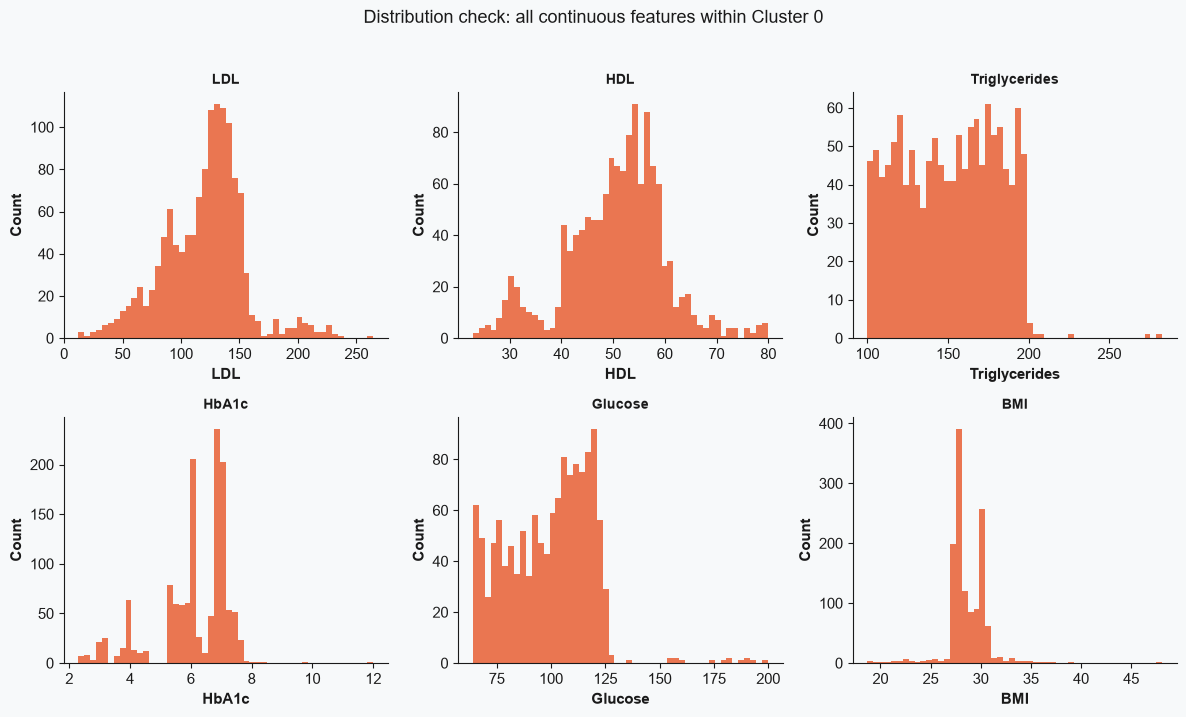

In [7]:
# [Step 4] - Visual check: Check 3

continuous_vars = ["LDL", "HDL", "Triglycerides", "HbA1c", "Glucose", "BMI"]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for var, ax in zip(continuous_vars, axes.flat):
    sns.histplot(cluster0[var], bins=50, color=ACCENT, edgecolor="none", ax=ax)
    ax.set_title(var, fontsize=10)
    sns.despine(ax=ax)

fig.suptitle("Distribution check: all continuous features within Cluster 0", y=1.02)
plt.tight_layout()
plt.show()

**Isolating the source of the artifact**

**Check 1:**<br>
The LDL vs HbA1c scatter, colored by `on_metformin`, did not show the expected pattern
(neither a clean diagonal continuum nor two separable blobs in LDL-HbA1c space).
Instead it revealed horizontal banding in HbA1c that cuts across the full LDL range,
an independent phenomenon from the metformin gradient under investigation.

**Check 2:**<br>
The HbA1c bands are present *within* both `on_metformin` groups, not aligned with
metformin status, this is a separate axis of variation, not the gradient itself.

**Check 3:**<br>
HbA1c and BMI show sharp, near-categorical density spikes, unlike the broader,
smoother multimodality of LDL/HDL/Triglycerides/Glucose, consistent with a Synthea
data-generation artifact (discrete clinical-state modules), not a genuine clinical
signal of discrete glycemic thresholds.

**The decisive observation is Glucose.** HbA1c and Glucose are physiologically
tightly coupled, two windows onto the same underlying glycemic control, one
averaged over months, one instantaneous. If the HbA1c banding reflected a real
clinical mechanism (e.g., discrete treatment targets), some trace of it should
propagate to Glucose as well. It does not: Glucose remains smooth and continuous.
This decoupling between two variables that should move together is stronger
evidence than the banding pattern alone, it localizes the artifact specifically
to how Synthea generates the HbA1c (and BMI) fields, rather than to the simulated
biology more broadly.

**Conclusion**: HbA1c/BMI banding is documented as a known synthetic-data
generation limitation, not a clinical signal, consistent with, and now better
substantiated than, the earlier BMI bimodality flag from the Phase 3 EDA. This
does not materially affect the validity of the main K=3 clustering result, since
the adopted clinical feature set is not dominated by these two variables alone.

**Step 5 — Final classification**

**Real continuous gradient, not a discrete sub-cluster.**

Evidence:
- **Step 2**: large, clinically coherent effect sizes across the full metabolic/glycemic
  panel (Mann-Whitney U, rank-biserial r), consistent with a treatment effect.
- **Step 3**: silhouette scores within Cluster 0 stay below 0.18 across K=2–7, with a
  monotonic rise after K=3, the signature of no genuine substructure, not of a
  missed optimal K.
- **Step 4**: no visual separation in LDL-HbA1c space; the only sharp structure found
  (HbA1c banding) is unrelated to metformin status and attributable to a data
  artifact, not a hidden sub-phenotype.